# Introducción y Configuración
En este proyecto construimos un Asesor de IA con dos objetivos principales. El primero es analizar la demanda de habilidades en el mercado de TI utilizando el dataset "LinkedIn Job Postings (2023–2024)" https://www.kaggle.com/datasets/arshkon/linkedin-job-postings , el cual contiene aproximadamente 124,000 ofertas laborales. El segundo objetivo es predecir el salario de un desarrollador empleando el dataset "Stack Overflow Developer Survey 2023", que incluye alrededor de 89,000 registros de información sobre profesionales del desarrollo https://www.kaggle.com/datasets/stackoverflow/stack-overflow-2023-developers-survey. Este NoteBook trabajará el primer objetivo

In [1]:
# --- 1. Configuración ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from flashtext import KeywordProcessor

print("Librerías cargadas.")

# --- 2. Carga de Archivos Mínimos ---
try:
    # Para el Filtro de TI
    df_li_postings = pd.read_csv('../../datasets/LinkedIn job posting/postings.csv', usecols=['job_id', 'description'], engine='python', on_bad_lines='skip')
    df_li_job_skills = pd.read_csv('../../datasets/LinkedIn job posting/job_skills.csv', on_bad_lines='skip')
    df_li_map_skills = pd.read_csv('../../datasets/LinkedIn job posting/skills.csv', on_bad_lines='skip')
    
    # Para el Diccionario de Habilidades
    df_onet_tech_skills = pd.read_excel('../../datasets/ONET/Technology Skills.xlsx')
    
    print("Archivos mínimos cargados exitosamente.")
    print(f"Total de postings (bruto): {df_li_postings.shape[0]}")

except Exception as e:
    print(f"Error al cargar archivos: {e}")

Librerías cargadas.
Archivos mínimos cargados exitosamente.
Total de postings (bruto): 123849


## Análisis de Demanda (LinkedIn) 
Comenzamos con +120,000 ofertas de trabajo de LinkedIn, divididas en más de 10 archivos. El objetivo era filtrar las ofertas de TI, fusionarlas y extraer habilidades granulares (Ej. Python, Docker, Java).
### Carga y Filtro de Datos Brutos

Necesitamos tener las filas correspondientes al sector TI, vamos a observar los valores únicos del archivo skills.csv, que contiene todas las habilidades del conjunto de datos y así poder filtrar correctamente.

In [2]:
print(df_li_map_skills)

   skill_abr              skill_name
0        ART            Art/Creative
1       DSGN                  Design
2       ADVR             Advertising
3       PRDM      Product Management
4       DIST            Distribution
5        EDU               Education
6       TRNG                Training
7       PRJM      Project Management
8       CNSL              Consulting
9       PRCH              Purchasing
10      SUPL            Supply Chain
11      ANLS                 Analyst
12      HCPR    Health Care Provider
13      RSCH                Research
14       SCI                 Science
15      GENB        General Business
16      CUST        Customer Service
17      STRA       Strategy/Planning
18       FIN                 Finance
19      OTHR                   Other
20       LGL                   Legal
21       ENG             Engineering
22        QA       Quality Assurance
23        BD    Business Development
24        IT  Information Technology
25       ADM          Administrative
2

Ya que identificamos cuáles son, vamos a hacer el filtrado.

In [3]:
# --- 3. Filtro Preciso de TI ---

# Definir nuestras 8 categorías de TI
it_skill_abr = ['IT', 'ENG', 'QA', 'ANLS', 'SCI', 'DSGN', 'PRDM', 'PRJM'] 
skill_regex = '|'.join(it_skill_abr)

# Crear el diccionario de habilidades de LinkedIn
df_skills_full = pd.merge(df_li_job_skills, df_li_map_skills, on='skill_abr', how='left')

# Encontrar los job_id que coinciden
it_skill_jobs = df_skills_full[df_skills_full['skill_abr'].str.contains(skill_regex, case=False, na=False)]
it_job_ids_from_skill = it_skill_jobs['job_id'].unique()

# Filtrar nuestro DataFrame principal
df_master_ti = df_li_postings[
    df_li_postings['job_id'].isin(it_job_ids_from_skill)
].copy()

print(f"Filtro completado. {df_master_ti.shape[0]} ofertas de TI aisladas.")


Filtro completado. 35085 ofertas de TI aisladas.


Para determinar la demanda real de habilidades en el mercado, nuestro objetivo es escanear nuestras 35,085 descripciones de trabajo de TI y contar la frecuencia de tecnologías específicas (como 'Python' o 'Java'). Los métodos de conteo simple fracasaron en nuestros intentos iniciales, ya que se inundaron con "ruido" genérico (palabras como "experiencia" o "equipo") y jerga de recursos humanos (como "disability" o "employment"). Para superar esto, implementamos un método de "diccionario" preciso, que nos permite buscar únicamente las habilidades técnicas que nos interesan, ignorando todo el ruido irrelevante.Para determinar la demanda real de habilidades en el mercado, nuestro objetivo es escanear nuestras 35,085 descripciones de trabajo de TI y contar la frecuencia de tecnologías específicas (como 'Python' o 'Java'). Los métodos de conteo simple fracasaron en nuestros intentos iniciales, ya que se inundaron con "ruido" genérico (palabras como "experiencia" o "equipo") y jerga de recursos humanos (como "disability" o "employment"). Para superar esto, implementamos un método de "diccionario" preciso, que nos permite buscar únicamente las habilidades técnicas que nos interesan, ignorando todo el ruido irrelevante.

Un desafío clave que descubrimos fue que las habilidades rara vez se mencionan con un solo nombre. Una búsqueda simple de la palabra "java", por ejemplo, fallaría. Nuestra investigación del diccionario O*NET reveló que las habilidades se listan con nombres formales y de marca, como "Oracle Java", "Enterprise JavaBeans" o "Oracle Java Enterprise Edition EE". De manera similar, 'js' es un alias común de 'JavaScript' y 'aws' lo es de 'Amazon Web Services'. Por lo tanto, nuestro sistema de escaneo debe ser lo suficientemente inteligente como para reconocer estos "alias" comunes en el texto y mapearlos al nombre técnico formal.

In [4]:
# ¿Qué posibles nombres tiene java?
try:
    print("--- Buscando 'Java' en el diccionario O*NET original ---")
    
    # Convertimos la columna a string (para evitar errores) y buscamos 'Java'
    java_skills = df_onet_tech_skills[
        df_onet_tech_skills['Example'].astype(str).str.contains('Java', case=False, na=False)
    ]
    
    if java_skills.empty:
        print("¡Increíble, 'Java' no está en el diccionario O*NET en absoluto!")
    else:
        print("¡Encontrado! Así es como O*NET llama a 'Java':")
        # Imprimir los nombres únicos que encontró
        print(java_skills['Example'].unique())

except Exception as e:
    print(f"Ocurrió un error: {e}")

--- Buscando 'Java' en el diccionario O*NET original ---
¡Encontrado! Así es como O*NET llama a 'Java':
['JavaScript' 'Oracle JavaServer Pages JSP' 'Enterprise JavaBeans'
 'Oracle Java' 'JavaScript Object Notation JSON'
 'Oracle Java 2 Platform Enterprise Edition J2EE'
 'Oracle Java Enterprise Edition EE' 'Xerces2 Java Parser'
 'JavaScript framework software' 'Oracle Java Message Service JMS'
 'Sun Microsystems Java Persistence API' 'YourKit Java Profiler'
 'Sun Microsystems Java Servlet API' 'Sun Microsystems Java'
 'Javamin Composer']


Nuestra solución fue un proceso de dos partes. Primero, usamos el archivo Technology Skills.xlsx de O*NET como nuestro "diccionario" profesional. Filtramos sus 8,775 habilidades para crear una "lista blanca" (whitelist) que contenía únicamente tecnologías asociadas a roles de TI, eliminando así el ruido genérico de otras industrias. Segundo, utilizamos FlashText, una biblioteca de alto rendimiento, para el escaneo. "Armamos" el procesador FlashText con nuestra lista blanca limpia y luego le enseñamos los "alias" que descubrimos (mapeando 'java' a 'oracle java' y 'aws' a 'amazon web services'). Este método nos permitió escanear las 35,085 descripciones de manera eficiente, encontrando y estandarizando solo las habilidades relevantes.

In [5]:
from flashtext import KeywordProcessor

try:
    print("Iniciando escaneo granular (Método Whitelist + Alias + Blacklist)...")

    # --- 1. Definir nuestros roles de TI ---
    ti_role_keywords = ['Software', 'Data', 'Developer', 'Computer', 'Web', 'Database', 'Network', 'Security', 'Programmer']
    
    # --- 2. Filtrar el Diccionario O*NET ---
    ti_role_regex = '|'.join(ti_role_keywords)
    df_ti_skills_dictionary = df_onet_tech_skills[
        df_onet_tech_skills['Title'].str.contains(ti_role_regex, case=False, na=False)
    ]

    # --- 3. Crear el "Diccionario Limpio" (Whitelist) ---
    clean_skill_list = df_ti_skills_dictionary['Example'].dropna().astype(str).str.lower().unique().tolist()
    
    # --- 3.5 ¡LA CORRECCIÓN! Remover Ruido Explícito (Blacklist) ---
    # O*NET a veces incluye estas palabras incluso en roles de TI. Las borramos aquí para siempre.
    noise_blacklist = [
        'linkedin','programming languages','google', 
        'analyze','reduce','e-verify', 'computer',
        'microsoft','twitter', 'facebook', 'youtube', 'zoom', 'slack', 
        'microsoft office software', 'microsoft word', 'microsoft excel',
        'project management software' 
    ]
    
    # Filtramos la lista para sacar el ruido
    clean_skill_list = [skill for skill in clean_skill_list if skill not in noise_blacklist]
    
    print(f"Diccionario LIMPIO (solo roles TI - Ruido): {len(clean_skill_list)} habilidades.")

    # --- 4. "Armar" el procesador FlashText ---
    keyword_processor = KeywordProcessor()
    keyword_processor.add_keywords_from_list(clean_skill_list)

    # --- 5. ALIAS (Mapeos manuales) ---
    print("Agregando alias manuales para habilidades clave...")
    
    # Java
    keyword_processor.add_keyword('java', 'oracle java')
    keyword_processor.add_keyword('j2ee', 'oracle java 2 platform enterprise edition j2ee')
    
    # JS & Web
    keyword_processor.add_keyword('js', 'javascript')
    keyword_processor.add_keyword('reactjs', 'react')
    keyword_processor.add_keyword('node', 'node.js')
    
    # Nube
    keyword_processor.add_keyword('aws', 'amazon web services')
    keyword_processor.add_keyword('azure', 'microsoft azure')
    keyword_processor.add_keyword('gcp', 'google cloud platform')
    
    # Python
    keyword_processor.add_keyword('python', 'python')

    # --- 6. Escanear (¡y limpiar duplicados en un solo paso!) ---
    df_master_ti['description'] = df_master_ti['description'].fillna('')
    df_master_ti['granular_skills_unique'] = df_master_ti['description'].apply(
        lambda x: list(set(keyword_processor.extract_keywords(x.lower())))
    )
    
    print("¡Escaneo granular completado! (El ruido ha sido eliminado desde la fuente).")
    
    # Inspección rápida
    print(df_master_ti[df_master_ti['granular_skills_unique'].apply(lambda x: len(x) > 0)][['granular_skills_unique']].head())

except Exception as e:
    print(f"Ocurrió un error: {e}")

Iniciando escaneo granular (Método Whitelist + Alias + Blacklist)...
Diccionario LIMPIO (solo roles TI - Ruido): 1409 habilidades.
Agregando alias manuales para habilidades clave...
¡Escaneo granular completado! (El ruido ha sido eliminado desde la fuente).
                                granular_skills_unique
11                                               [ada]
26                            [php, javascript, mysql]
78   [amazon web services, typescript, nosql, pytho...
87                                              [chef]
108                     [github, oracle java, postman]


Una vez completado el escaneo, cada oferta de trabajo tenía una lista de habilidades granulares y limpias. Para analizar la demanda, "explotamos" estas listas y contamos la frecuencia de cada habilidad para generar nuestro gráfico (mostrando python y docker  como habilidades clave). Más importante aún, esto potenció nuestro motor de recomendación. Al aislar las ofertas que contenían una habilidad (como 'docker') y luego contar las otras habilidades que co-ocurrían en ese subconjunto (como kubernetes ), pudimos construir un recomendador preciso basado en la sinergia real del mercado.

Calculando la demanda de habilidades granulares...

--- Demanda de Habilidades Específicas (Top 20) ---
granular_skills_unique
python                                            3968
amazon web services                               2784
microsoft azure                                   2611
go                                                2605
oracle java                                       2357
c                                                 2281
r                                                 2146
javascript                                        1952
linux                                             1517
c++                                               1184
git                                               1085
c#                                                1084
kubernetes                                        1060
react                                             1016
docker                                             969
google cloud platform                           

C:\Users\flore\AppData\Local\Temp\ipykernel_5800\4291651720.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_skills.values, y=top_20_skills.index, palette='viridis')


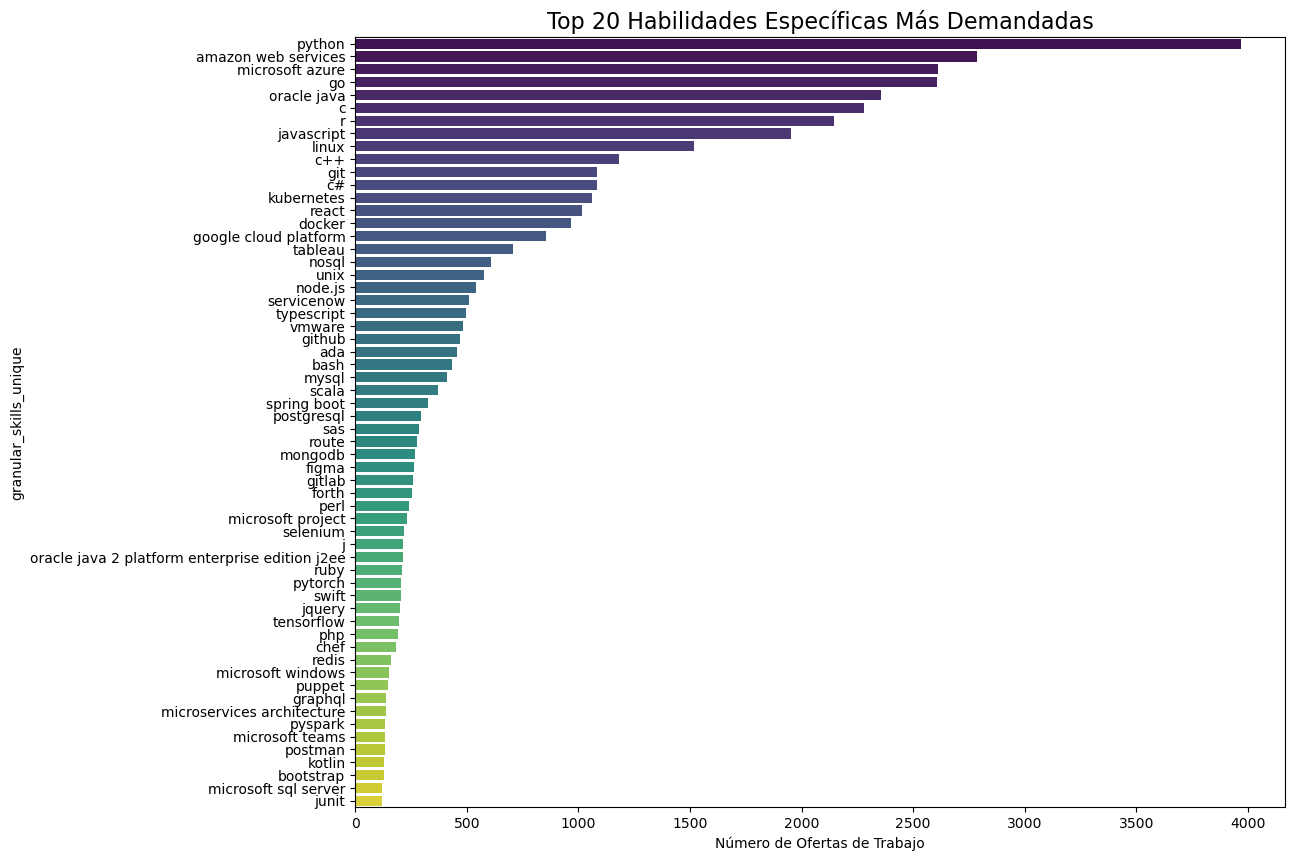

In [6]:
# --- 5. Análisis de Demanda (Top 20) ---
try:
    print("Calculando la demanda de habilidades granulares...")

    # "Explotar" el DataFrame para contar las habilidades
    df_exploded = df_master_ti.explode('granular_skills_unique')
    
    # Contar la frecuencia
    granular_demand = df_exploded['granular_skills_unique'].value_counts()

    print("\n--- Demanda de Habilidades Específicas (Top 20) ---")
    top_20_skills = granular_demand.head(60)
    print(top_20_skills)

    # Visualización
    plt.figure(figsize=(12, 10))
    sns.barplot(x=top_20_skills.values, y=top_20_skills.index, palette='viridis')
    plt.title('Top 20 Habilidades Específicas Más Demandadas', fontsize=16)
    plt.xlabel('Número de Ofertas de Trabajo')
    plt.show()

except Exception as e:
    print(f"Ocurrió un error: {e}")

Aquí respondemos la segunda pregunta: "Si sé Python, ¿qué más aprendo?"

In [7]:
# --- 6. Motor de Recomendación (v2.0) ---

# Lista de ruido que descubrimos (opcional, pero mejora las recs)
noise_skills = ['analyze', 'go', 'c', 'r', 'reduce', 'google', 'linkedin', 
                'programming languages', 'e-verify', 'c#', 'c++']

def get_recommendations_v2(skill_name, df_with_skills):
    print(f"\n--- Recomendaciones (Co-ocurrencia) para: {skill_name} ---")
    
    # 1. Filtrar trabajos que mencionan la habilidad
    jobs_with_skill = df_with_skills[df_with_skills['granular_skills_unique'].apply(
        lambda skills_list: skill_name in skills_list
    )]
    
    print(f"Se encontraron {len(jobs_with_skill)} trabajos que mencionan '{skill_name}'.")

    # 2. "Explotar" solo ese subconjunto
    df_exploded_subset = jobs_with_skill.explode('granular_skills_unique')
    
    # 3. Contar la frecuencia de todas las otras habilidades
    skill_counts = df_exploded_subset['granular_skills_unique'].value_counts()
    
    # 4. Limpiar la lista (quitarse a sí misma y al ruido)
    skill_counts = skill_counts.drop(skill_name, errors='ignore')
    skill_counts = skill_counts.drop(labels=noise_skills, errors='ignore')
    
    return skill_counts.head(5)

# --- Demostración Final ---
try:
    recs_docker = get_recommendations_v2('microsoft azure', df_master_ti)
    print(recs_docker)
    
    recs_python = get_recommendations_v2('oracle java', df_master_ti)
    print(recs_python)

except Exception as e:
    print(f"Ocurrió un error: {e}")


--- Recomendaciones (Co-ocurrencia) para: microsoft azure ---
Se encontraron 2611 trabajos que mencionan 'microsoft azure'.
granular_skills_unique
amazon web services      1234
python                    927
oracle java               564
kubernetes                512
google cloud platform     503
Name: count, dtype: int64

--- Recomendaciones (Co-ocurrencia) para: oracle java ---
Se encontraron 2357 trabajos que mencionan 'oracle java'.
granular_skills_unique
python                 1084
amazon web services     826
javascript              680
microsoft azure         564
kubernetes              452
Name: count, dtype: int64


Guardamos el dataframe


In [8]:
import os

try:
    # Definimos un nombre de archivo claro para la Misión 1
    file_name = 'mision_1_demanda_habilidades.pkl'

    # Guardamos el DataFrame que tiene las habilidades granulares
    df_master_ti.to_pickle(file_name)
    
    print(f"¡DataFrame de la Misión 1 guardado exitosamente como '{file_name}'!")
    print(f"Tamaño del archivo: {os.path.getsize(file_name) / (1024*1024):.2f} MB")

except Exception as e:
    print(f"Ocurrió un error al guardar el archivo: {e}")
    print("Asegúrate de que la variable 'df_master_ti' exista.")

¡DataFrame de la Misión 1 guardado exitosamente como 'mision_1_demanda_habilidades.pkl'!
Tamaño del archivo: 115.35 MB


In [9]:
import json
import os

try:
    # (Asegurándonos de que 'clean_skill_list' exista en memoria)
    if 'clean_skill_list' not in locals():
        print("Error: 'clean_skill_list' no existe.")
        print("Por favor, vuelve a ejecutar la celda del 'Paso 3 (Corregido)' para crearla.")
    else:
        # Definimos el nombre del archivo
        json_filename = 'skills_whitelist.json'

        # Guardamos la lista de Python directamente en un archivo JSON
        with open(json_filename, 'w') as f:
            json.dump(clean_skill_list, f)
        
        print(f"¡Lista de {len(clean_skill_list)} habilidades guardada exitosamente como '{json_filename}'!")
        print(f"Tamaño del archivo: {os.path.getsize(json_filename) / 1024:.2f} KB")
        print("\nTu frontend ahora puede usar este archivo para crear un menú desplegable.")

except Exception as e:
    print(f"Ocurrió un error: {e}")

¡Lista de 1409 habilidades guardada exitosamente como 'skills_whitelist.json'!
Tamaño del archivo: 36.89 KB

Tu frontend ahora puede usar este archivo para crear un menú desplegable.
